# Titanic Survival prediction 泰坦尼克號生還者預測
本專題將以泰坦尼克號乘客資料為基礎，建立分類模型來預測乘客是否能夠生還。  
接下來將依序進行資料清理、特徵選擇、缺失值處理與數值編碼，並使用多種機器學習演算法進行分析與比較。

本研究將先以 Decision Tree 作為基礎模型，接著延伸至 Logistic Regression、Random Forest、SVM 等方法，觀察不同模型在準確率、ROC-AUC、混淆矩陣與分類報告上的表現差異。  
最後將綜合比較各模型的預測能力，找出較適合此資料集的分類方法。

### Decision Tree 分析

在本節中，我們先使用 Decision Tree 來建立泰坦尼克號生還者預測模型。  
Decision Tree 的優點是結構清楚、容易解釋，能快速看出哪些特徵對生還結果影響較大，因此適合作為本研究的基礎模型與比較基準。

本節將依序完成資料前處理、特徵編碼、模型訓練、預測與評估，並透過準確率、ROC-AUC、混淆矩陣、分類報告與特徵重要度來觀察模型表現。  
同時也會視覺化決策樹，方便理解模型的判斷規則。

訓練資料: (891, 12)
測試資料: (418, 11)
訓練資料欄位: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

=== Sex 編碼驗證 ===
Sex value_counts:
Sex
0    577
1    314
Name: count, dtype: int64
Sex null count: 0

=== Embarked 編碼驗證 ===
Embarked value_counts:
Embarked
0    646
1    168
2     77
Name: count, dtype: int64
Embarked null count: 0

=== Dropna 前資料量 ===
Original: 891
After dropna: 891
Test set: 418

=== Sex 對生存率的影響 ===
Sex
0.0    0.188908
1.0    0.742038
Name: Survived, dtype: float64
(預期: female(1) 生存率應明顯高於 male(0))

訓練特徵形狀: (891, 9)
測試特徵形狀: (418, 9)
使用的特徵: ['Age', 'Fare', 'Sex', 'SibSp', 'Parch', 'Pclass', 'Embarked', 'FamilySize', 'IsAlone']

訓練集分割:
  訓練集: (712, 9)
  驗證集: (179, 9)

Decision Tree 交叉驗證結果（train_split）
Accuracy: 0.7711 (+/- 0.0218)
ROC-AUC: 0.8287 (+/- 0.0354)

Decision Tree 驗證集評估（最重要）

混淆矩陣（驗證集）:
[[83 27]
 [10 59]]

分類報告（驗證集）:
              precision    recall  f1-score   support

        Died       0.89      0.75 

<Figure size 600x400 with 0 Axes>

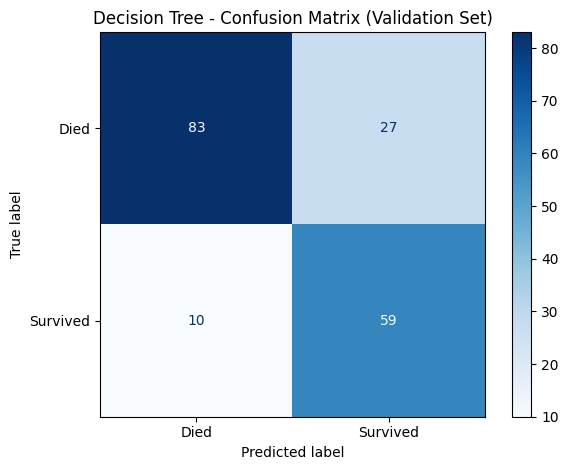


Feature Importance（排序，檢查所有特徵是否有 contribution）
      Feature  Importance
0         Sex    0.603135
1         Age    0.119169
2      Pclass    0.101222
3  FamilySize    0.095778
4        Fare    0.069321
5    Embarked    0.011375
6       SibSp    0.000000
7       Parch    0.000000
8     IsAlone    0.000000

=== Sanity Check ===
✓ Sex importance: 0.6031 (應 > 0)
✓ Pclass importance: 0.1012
✓ Fare importance: 0.0693
✓ Age importance: 0.1192


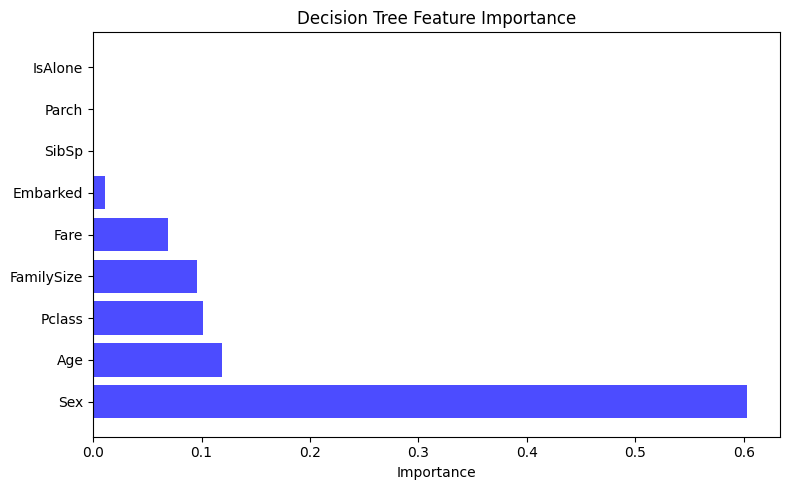

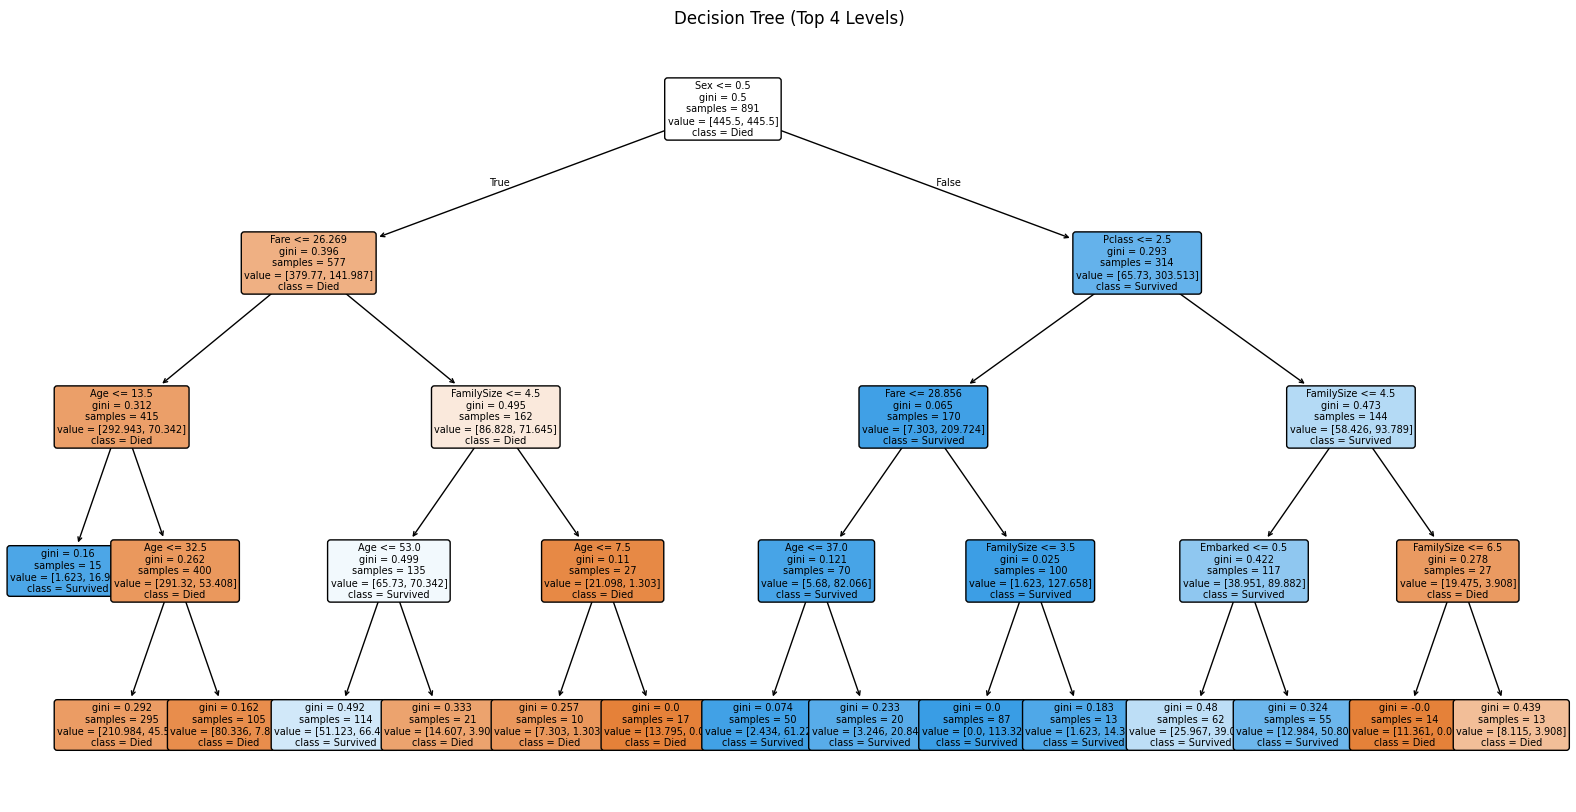

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    )

# =========================
# 0. 定義統一的資料前處理函數
# =========================
def preprocess_data(df):
    """統一的資料前處理函數"""
    df = df.copy()
    
    # 刪掉 Ticket、Cabin（通常缺失太多）
    df = df.drop(columns=["Ticket", "Cabin"], errors="ignore")
    
    # 刪掉所有叫 zero 的欄位
    df = df.loc[:, ~df.columns.str.contains(r"^zero", case=False)]
    
    # 修正常見欄位名稱
    rename_map = {
        "2urvived": "Survived",
        "sibsp": "SibSp",
    }
    df = df.rename(columns=rename_map)
    
    # =========================
    # 優先填補缺失值（避免過度刪資料）
    # =========================
    if "Age" in df.columns:
        df["Age"] = df["Age"].fillna(df["Age"].median())
    if "Fare" in df.columns:
        df["Fare"] = df["Fare"].fillna(df["Fare"].median())
    if "Embarked" in df.columns:
        df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
    
    # =========================
    # Feature Engineering（在編碼之前）
    # =========================
    if "SibSp" in df.columns and "Parch" in df.columns:
        df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    
    if "FamilySize" in df.columns:
        df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
    
    # =========================
    # 編碼（使用 map，檢查 null）
    # =========================
    if "Sex" in df.columns:
        df["Sex"] = (
            df["Sex"]
            .astype(str)
            .str.lower()
            .map({"male": 0, "female": 1})
        )
    
    if "Embarked" in df.columns:
        df["Embarked"] = (
            df["Embarked"]
            .astype(str)
            .str.upper()
            .map({"S": 0, "C": 1, "Q": 2})
        )
    
    # Target 轉整數（若有 Survived 欄位）
    if "Survived" in df.columns:
        df["Survived"] = pd.to_numeric(df["Survived"], errors="coerce")
    
    return df

# =========================
# 1. 讀資料（改用官方分割）
# =========================
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

print("訓練資料:", df_train.shape)
print("測試資料:", df_test.shape)
print("訓練資料欄位:", df_train.columns.tolist())

# =========================
# 2. 資料前處理
# =========================
df_train = preprocess_data(df_train)
df_test = preprocess_data(df_test)

# =========================
# 3. Sex 編碼驗證（檢查 null）
# =========================
print("\n=== Sex 編碼驗證 ===")
print("Sex value_counts:")
print(df_train["Sex"].value_counts())
print(f"Sex null count: {df_train['Sex'].isnull().sum()}")

# =========================
# 4. Embarked 編碼驗證（檢查 null）
# =========================
print("\n=== Embarked 編碼驗證 ===")
print("Embarked value_counts:")
print(df_train["Embarked"].value_counts())
print(f"Embarked null count: {df_train['Embarked'].isnull().sum()}")

# =========================
# 5. 移除編碼失敗的資料（dropna 策略最優化）
# =========================
print("\n=== Dropna 前資料量 ===")
print(f"Original: {len(df_train)}")

df_train = df_train.dropna(
    subset=["Sex", "Embarked", "Survived"]
).copy()

print(f"After dropna: {len(df_train)}")

# 轉型別
df_train["Sex"] = df_train["Sex"].astype(float)
df_train["Embarked"] = df_train["Embarked"].astype(float)
df_train["Survived"] = df_train["Survived"].astype(int)

# 測試集移除必要的缺失值
df_test = df_test.dropna(subset=["Sex", "Embarked"]).copy()
df_test["Sex"] = df_test["Sex"].astype(float)
df_test["Embarked"] = df_test["Embarked"].astype(float)
print(f"Test set: {len(df_test)}")

# =========================
# 6. 驗證 Sex 對生存率的影響
# =========================
print("\n=== Sex 對生存率的影響 ===")
print(df_train.groupby("Sex")["Survived"].mean())
print("(預期: female(1) 生存率應明顯高於 male(0))")

# =========================
# 7. 選特徵（包含新特徵）
# =========================
features = [
    "Age",
    "Fare",
    "Sex",
    "SibSp",
    "Parch",
    "Pclass",
    "Embarked",
    "FamilySize",
    "IsAlone"
]

X_train = df_train[features].astype(float)
y_train = df_train["Survived"]
X_test = df_test[features].astype(float)

print(f"\n訓練特徵形狀: {X_train.shape}")
print(f"測試特徵形狀: {X_test.shape}")
print(f"使用的特徵: {features}")

# =========================
# 8. 創建驗證集（train/test split）
# =========================
X_train_split, X_valid, y_train_split, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print(f"\n訓練集分割:")
print(f"  訓練集: {X_train_split.shape}")
print(f"  驗證集: {X_valid.shape}")

# =========================
# 9. 訓練與交叉驗證（使用 train_split）
# =========================
model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    min_samples_split=20,  # 增強 regularization，避免過度細分
    class_weight="balanced",  # 處理類別不平衡
    random_state=42
)

# 使用交叉驗證評估模型（使用 train_split）
cv_results = cross_validate(
    model,
    X_train_split,
    y_train_split,
    cv=5,
    scoring=["accuracy", "roc_auc"],
    return_train_score=True
)

print("\n" + "=" * 50)
print("Decision Tree 交叉驗證結果（train_split）")
print("=" * 50)
print(f"Accuracy: {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
print(f"ROC-AUC: {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std():.4f})")

# 用完整訓練集訓練最終模型
model.fit(X_train, y_train)

# =========================
# 10. 使用驗證集評估（而非訓練集）
# =========================
print("\n" + "=" * 50)
print("Decision Tree 驗證集評估（最重要）")
print("=" * 50)

y_valid_pred = model.predict(X_valid)

# 混淆矩陣
cm = confusion_matrix(y_valid, y_valid_pred)
print("\n混淆矩陣（驗證集）:")
print(cm)

# 分類報告
print("\n分類報告（驗證集）:")
print(classification_report(y_valid, y_valid_pred, target_names=["Died", "Survived"]))

# 驗證集準確度
valid_accuracy = accuracy_score(y_valid, y_valid_pred)
valid_auc = roc_auc_score(y_valid, y_valid_pred)
print(f"\nValidation Set Accuracy: {valid_accuracy:.4f}")
print(f"Validation Set ROC-AUC: {valid_auc:.4f}")

# 可視化混淆矩陣
plt.figure(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Died", "Survived"])
disp.plot(cmap="Blues")
plt.title("Decision Tree - Confusion Matrix (Validation Set)")
plt.tight_layout()
plt.show()

# =========================
# 11. 特徵重要度（sanity check）
# =========================
importance_df = (
    pd.DataFrame({"Feature": features, "Importance": model.feature_importances_})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 50)
print("Feature Importance（排序，檢查所有特徵是否有 contribution）")
print("=" * 50)
print(importance_df)

# Sanity check
print("\n=== Sanity Check ===")
print(f"✓ Sex importance: {model.feature_importances_[features.index('Sex')]:.4f} (應 > 0)")
print(f"✓ Pclass importance: {model.feature_importances_[features.index('Pclass')]:.4f}")
print(f"✓ Fare importance: {model.feature_importances_[features.index('Fare')]:.4f}")
print(f"✓ Age importance: {model.feature_importances_[features.index('Age')]:.4f}")

# 特徵重要度圖
plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="blue", alpha=0.7)
plt.xlabel("Importance")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

# =========================
# 12. 可視化決策樹（max_depth=4 避免過複雜）
# =========================
plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=features,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=4,  # 簡化視覺化，避免過於複雜
    fontsize=7,   # 減少字體大小以容納更多節點
    rounded=True  # 使節點邊界圓形，視覺上更緊湊
)
plt.title("Decision Tree (Top 4 Levels)")
plt.show()

### Random Forest分析

使用 Random Forest 演算法分析 Titanic 乘客生存資料，探討不同特徵對生存機率的影響。相較於單一 Decision Tree，Random Forest 透過多棵決策樹的集成投票方式，降低過度擬合問題並提升模型穩定性。研究中以年齡、性別、票價、艙等與家庭同行人數等特徵作為輸入，建立乘客生存預測模型，並透過分類指標與特徵重要度分析模型表現與決策依據。

Random Forest 交叉驗證結果（train_split）
Accuracy: 0.8161 (+/- 0.0309)
ROC-AUC: 0.8682 (+/- 0.0221)

Random Forest 驗證集評估（最重要）

混淆矩陣（驗證集）:
[[92 18]
 [15 54]]

分類報告（驗證集）:
              precision    recall  f1-score   support

        Died       0.86      0.84      0.85       110
    Survived       0.75      0.78      0.77        69

    accuracy                           0.82       179
   macro avg       0.80      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179


Validation Set Accuracy: 0.8156
Validation Set ROC-AUC: 0.8095


<Figure size 600x400 with 0 Axes>

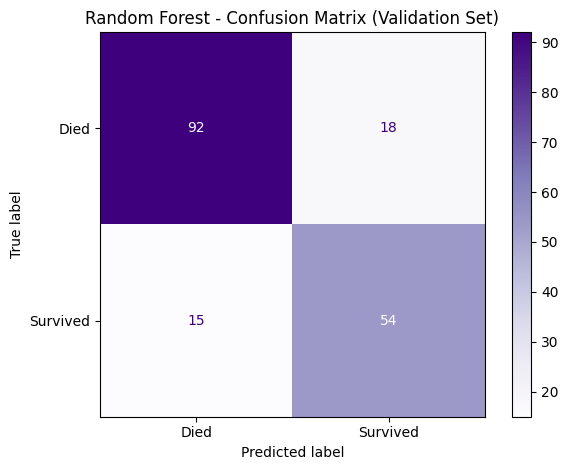


Feature Importance（排序，檢查所有特徵是否有 contribution）
      Feature  Importance
0         Sex    0.531519
1        Fare    0.142509
2      Pclass    0.128279
3         Age    0.070922
4  FamilySize    0.060361
5       SibSp    0.020218
6       Parch    0.016963
7     IsAlone    0.016081
8    Embarked    0.013146

=== Sanity Check ===
✓ Sex importance: 0.5315 (應 > 0)
✓ Pclass importance: 0.1283
✓ Fare importance: 0.1425
✓ Age importance: 0.0709


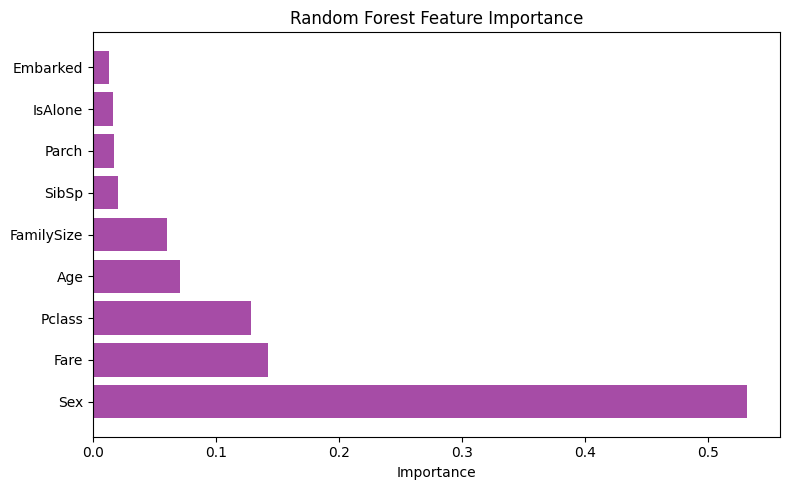

In [43]:
# =========================
# Random Forest 模型訓練與交叉驗證
# =========================
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=10,
    min_samples_split=20,  # 增強 regularization
    class_weight="balanced",  # 處理類別不平衡
    random_state=42,
    n_jobs=-1  # 使用所有 CPU 核心加速
)

# 使用交叉驗證評估模型（使用 train_split）
cv_results_rf = cross_validate(
    rf_model,
    X_train_split,
    y_train_split,
    cv=5,
    scoring=["accuracy", "roc_auc"],
    return_train_score=True
)

print("=" * 50)
print("Random Forest 交叉驗證結果（train_split）")
print("=" * 50)
print(f"Accuracy: {cv_results_rf['test_accuracy'].mean():.4f} (+/- {cv_results_rf['test_accuracy'].std():.4f})")
print(f"ROC-AUC: {cv_results_rf['test_roc_auc'].mean():.4f} (+/- {cv_results_rf['test_roc_auc'].std():.4f})")

# 用完整訓練集訓練最終模型
rf_model.fit(X_train, y_train)

# =========================
# 使用驗證集評估（而非訓練集）
# =========================
print("\n" + "=" * 50)
print("Random Forest 驗證集評估（最重要）")
print("=" * 50)

y_valid_pred_rf = rf_model.predict(X_valid)

# 混淆矩陣
cm_rf = confusion_matrix(y_valid, y_valid_pred_rf)
print("\n混淆矩陣（驗證集）:")
print(cm_rf)

# 分類報告
print("\n分類報告（驗證集）:")
print(classification_report(y_valid, y_valid_pred_rf, target_names=["Died", "Survived"]))

# 驗證集準確度
valid_accuracy_rf = accuracy_score(y_valid, y_valid_pred_rf)
valid_auc_rf = roc_auc_score(y_valid, y_valid_pred_rf)
print(f"\nValidation Set Accuracy: {valid_accuracy_rf:.4f}")
print(f"Validation Set ROC-AUC: {valid_auc_rf:.4f}")

# 可視化混淆矩陣
plt.figure(figsize=(6, 4))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Died", "Survived"])
disp_rf.plot(cmap="Purples")
plt.title("Random Forest - Confusion Matrix (Validation Set)")
plt.tight_layout()
plt.show()

# =========================
# Random Forest 特徵重要度（sanity check）
# =========================
importance_rf_df = (
    pd.DataFrame({"Feature": features, "Importance": rf_model.feature_importances_})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)
print("\n" + "=" * 50)
print("Feature Importance（排序，檢查所有特徵是否有 contribution）")
print("=" * 50)
print(importance_rf_df)

# Sanity check
print("\n=== Sanity Check ===")
print(f"✓ Sex importance: {rf_model.feature_importances_[features.index('Sex')]:.4f} (應 > 0)")
print(f"✓ Pclass importance: {rf_model.feature_importances_[features.index('Pclass')]:.4f}")
print(f"✓ Fare importance: {rf_model.feature_importances_[features.index('Fare')]:.4f}")
print(f"✓ Age importance: {rf_model.feature_importances_[features.index('Age')]:.4f}")

# 特徵重要度圖
plt.figure(figsize=(8, 5))
plt.barh(importance_rf_df["Feature"], importance_rf_df["Importance"], color="purple", alpha=0.7)
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

### Logistic Regression 分析

本節將使用 Logistic Regression 建立泰坦尼克號生還預測模型。  
Logistic Regression 是適合二元分類的經典方法，能夠輸出生還機率，並清楚分析各特徵對結果的影響方向。

在這裡，它的角色主要是作為一個簡潔、穩定且可解釋的比較模型，與 Decision Tree、Random Forest、SVM 的結果進行對照。

Logistic Regression 交叉驗證結果（train_split）
Accuracy: 0.7936 (+/- 0.0230)
ROC-AUC: 0.8584 (+/- 0.0218)

Logistic Regression 驗證集評估（最重要）

混淆矩陣（驗證集）:
[[97 13]
 [21 48]]

分類報告（驗證集）:
              precision    recall  f1-score   support

        Died       0.82      0.88      0.85       110
    Survived       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179


Validation Set Accuracy: 0.8101
Validation Set ROC-AUC: 0.7887


<Figure size 600x400 with 0 Axes>

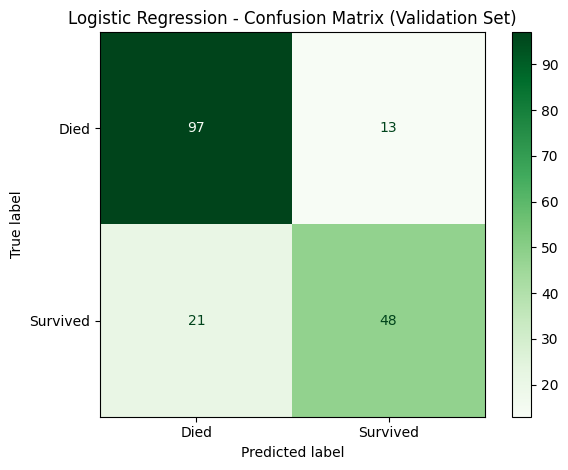


Logistic Regression Coefficients（排序）
      Feature  Coefficient
0         Sex     1.246914
1      Pclass    -0.876962
2         Age    -0.495844
3       SibSp    -0.386767
4     IsAlone    -0.376284
5  FamilySize    -0.290941
6    Embarked     0.141569
7        Fare     0.090991
8       Parch    -0.053241

=== Sanity Check ===
✓ Sex coefficient: 1.2469 (最大的係數之一)
✓ Pclass coefficient: -0.8770
✓ Age coefficient: -0.4958


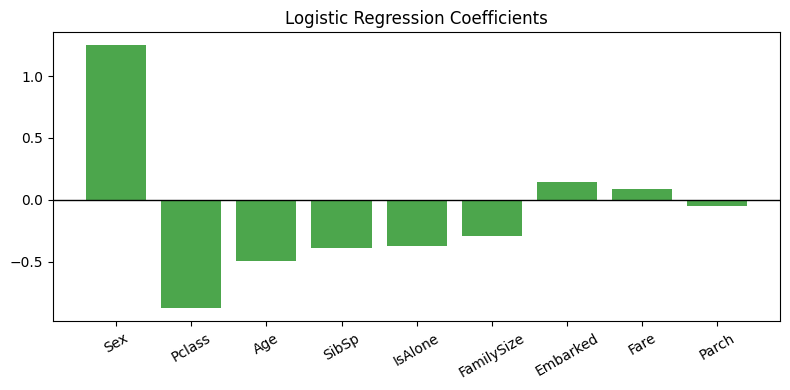

In [44]:
# =========================
# Logistic Regression 模型訓練與交叉驗證
# =========================

# Logistic Regression 對尺度較敏感，需先標準化
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=1000,
        random_state=42
    )),
])

# 使用交叉驗證評估模型（使用 train_split）
cv_results_lr = cross_validate(
    lr_model,
    X_train_split,
    y_train_split,
    cv=5,
    scoring=["accuracy", "roc_auc"],
    return_train_score=True
)

print("=" * 50)
print("Logistic Regression 交叉驗證結果（train_split）")
print("=" * 50)
print(f"Accuracy: {cv_results_lr['test_accuracy'].mean():.4f} (+/- {cv_results_lr['test_accuracy'].std():.4f})")
print(f"ROC-AUC: {cv_results_lr['test_roc_auc'].mean():.4f} (+/- {cv_results_lr['test_roc_auc'].std():.4f})")

# 用完整訓練集訓練最終模型
lr_model.fit(X_train, y_train)

# =========================
# 使用驗證集評估（而非訓練集）
# =========================
print("\n" + "=" * 50)
print("Logistic Regression 驗證集評估（最重要）")
print("=" * 50)

y_valid_pred_lr = lr_model.predict(X_valid)

# 混淆矩陣
cm_lr = confusion_matrix(y_valid, y_valid_pred_lr)
print("\n混淆矩陣（驗證集）:")
print(cm_lr)

# 分類報告
print("\n分類報告（驗證集）:")
print(classification_report(y_valid, y_valid_pred_lr, target_names=["Died", "Survived"]))

# 驗證集準確度
valid_accuracy_lr = accuracy_score(y_valid, y_valid_pred_lr)
valid_auc_lr = roc_auc_score(y_valid, y_valid_pred_lr)
print(f"\nValidation Set Accuracy: {valid_accuracy_lr:.4f}")
print(f"Validation Set ROC-AUC: {valid_auc_lr:.4f}")

# 可視化混淆矩陣
plt.figure(figsize=(6, 4))
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["Died", "Survived"])
disp_lr.plot(cmap="Greens")
plt.title("Logistic Regression - Confusion Matrix (Validation Set)")
plt.tight_layout()
plt.show()

# =========================
# Logistic Regression 係數解讀
# =========================
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr_model.named_steps["logreg"].coef_[0],
})
coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoefficient", ascending=False).reset_index(drop=True)

print("\n" + "=" * 50)
print("Logistic Regression Coefficients（排序）")
print("=" * 50)
print(coef_df[["Feature", "Coefficient"]])

# Sanity check
print("\n=== Sanity Check ===")
print(f"✓ Sex coefficient: {lr_model.named_steps['logreg'].coef_[0][features.index('Sex')]:.4f} (最大的係數之一)")
print(f"✓ Pclass coefficient: {lr_model.named_steps['logreg'].coef_[0][features.index('Pclass')]:.4f}")
print(f"✓ Age coefficient: {lr_model.named_steps['logreg'].coef_[0][features.index('Age')]:.4f}")

# 係數圖
plt.figure(figsize=(8, 4))
plt.bar(coef_df["Feature"], coef_df["Coefficient"], color="green", alpha=0.7)
plt.axhline(0, color="black", linewidth=1)
plt.title("Logistic Regression Coefficients")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 測試集預測與提交

使用訓練好的模型對官方測試集進行預測，並生成提交檔案。本節將使用 Random Forest 模型進行預測（因其表現通常較好），同時也可選擇其他模型進行對比。

✓ Random Forest 提交檔案已儲存：submission_rf.csv
提交資料數量: 418
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

三個模型的預測一致性（測試集）
Decision Tree vs Random Forest: 379/418 一致 (90.7%)
Decision Tree vs Logistic Regression: 361/418 一致 (86.4%)
Random Forest vs Logistic Regression: 386/418 一致 (92.3%)

三個模型的訓練集混淆矩陣比較


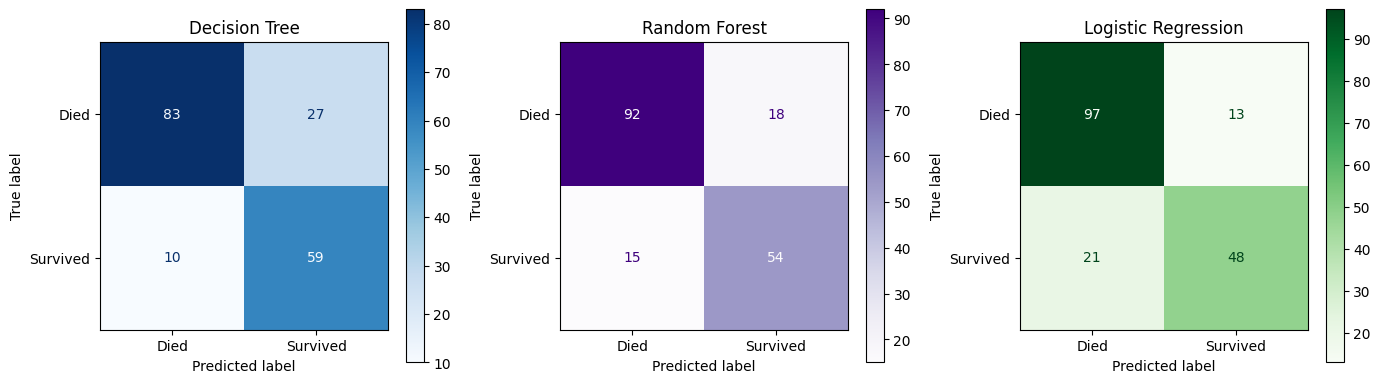

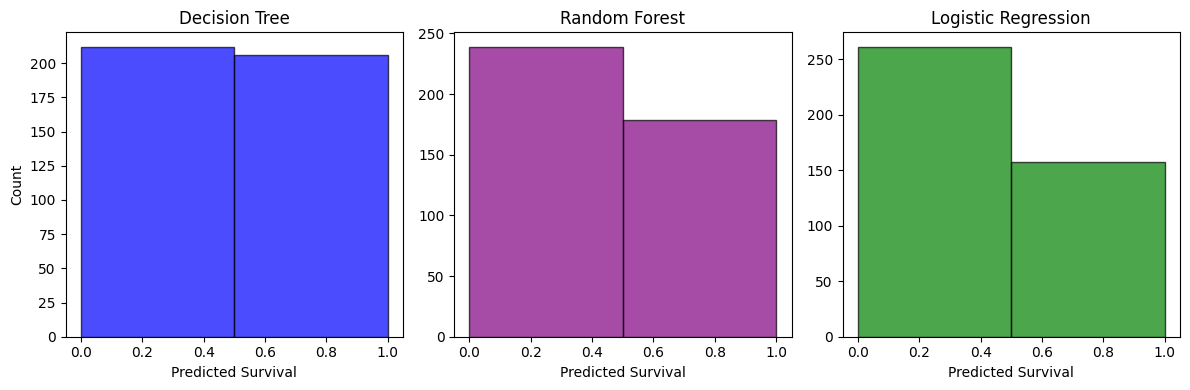


=== 測試集預測統計 ===
Decision Tree 預測生還: 206, 未生還: 212
Random Forest 預測生還: 179, 未生還: 239
Logistic Regression 預測生還: 157, 未生還: 261


In [45]:
# =========================
# 在測試集上進行預測
# =========================

# 使用 Random Forest 模型進行預測
y_pred_test = rf_model.predict(X_test)

# 生成提交檔案
submission = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": y_pred_test
})

submission.to_csv("submission_rf.csv", index=False)
print("✓ Random Forest 提交檔案已儲存：submission_rf.csv")
print(f"提交資料數量: {len(submission)}")
print(submission.head(10))

# =========================
# 三個模型的預測對比
# =========================

# Decision Tree 預測
y_pred_dt = model.predict(X_test)
submission_dt = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": y_pred_dt
})

# Logistic Regression 預測（使用已有的 y_pred_lr 來自訓練集預測，重新計算測試集）
y_pred_lr_test = lr_model.predict(X_test)
submission_lr = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": y_pred_lr_test
})

print("\n" + "="*50)
print("三個模型的預測一致性（測試集）")
print("="*50)

# 計算模型之間的一致性
dt_rf_agree = (y_pred_dt == y_pred_test).sum()
dt_lr_agree = (y_pred_dt == y_pred_lr_test).sum()
rf_lr_agree = (y_pred_test == y_pred_lr_test).sum()

print(f"Decision Tree vs Random Forest: {dt_rf_agree}/{len(y_pred_test)} 一致 ({100*dt_rf_agree/len(y_pred_test):.1f}%)")
print(f"Decision Tree vs Logistic Regression: {dt_lr_agree}/{len(y_pred_lr_test)} 一致 ({100*dt_lr_agree/len(y_pred_lr_test):.1f}%)")
print(f"Random Forest vs Logistic Regression: {rf_lr_agree}/{len(y_pred_lr_test)} 一致 ({100*rf_lr_agree/len(y_pred_lr_test):.1f}%)")

# =========================
# 三個模型的混淆矩陣比較
# =========================
print("\n" + "="*50)
print("三個模型的訓練集混淆矩陣比較")
print("="*50)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Decision Tree 混淆矩陣
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Died", "Survived"])
disp_dt.plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Decision Tree")

# Random Forest 混淆矩陣
disp_rf_plot = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Died", "Survived"])
disp_rf_plot.plot(ax=axes[1], cmap="Purples")
axes[1].set_title("Random Forest")

# Logistic Regression 混淆矩陣
disp_lr_plot = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["Died", "Survived"])
disp_lr_plot.plot(ax=axes[2], cmap="Greens")
axes[2].set_title("Logistic Regression")

plt.tight_layout()
plt.show()

# =========================
# 視覺化三個模型的預測分布
# =========================
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].hist(y_pred_dt, bins=[0, 0.5, 1], alpha=0.7, edgecolor='black', color='blue')
axes[0].set_title('Decision Tree')
axes[0].set_xlabel('Predicted Survival')
axes[0].set_ylabel('Count')

axes[1].hist(y_pred_test, bins=[0, 0.5, 1], alpha=0.7, edgecolor='black', color='purple')
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted Survival')

axes[2].hist(y_pred_lr_test, bins=[0, 0.5, 1], alpha=0.7, edgecolor='black', color='green')
axes[2].set_title('Logistic Regression')
axes[2].set_xlabel('Predicted Survival')

plt.tight_layout()
plt.show()

print(f"\n=== 測試集預測統計 ===")
print(f"Decision Tree 預測生還: {y_pred_dt.sum()}, 未生還: {(1-y_pred_dt).sum()}")
print(f"Random Forest 預測生還: {y_pred_test.sum()}, 未生還: {(1-y_pred_test).sum()}")
print(f"Logistic Regression 預測生還: {y_pred_lr_test.sum()}, 未生還: {(1-y_pred_lr_test).sum()}")

# SVM 不同kernel function的結果，